In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls /content/drive/MyDrive

 A1_starter.gdoc
'Akuol Chan BPK 408 Assignmnet01.gdoc'
'Akuol Resume .pdf'
'Assignment 2 BPK408 W.gdoc'
'Assignment 4 BPK408 .gdoc'
 Bisc300.gslides
'bpk408 '
'BPK 408 Assignment 3 Akuol Chan.gdoc'
'BUS 251 tut.gdoc'
 Classroom
'Colab Notebooks'
"Cracks in the Foundation: The Housing Crisis and Its Impact on BC's Drug Crisis.gslides"
"Debbie's"
'Getting started.pdf'
'Group M BUS 200.gdoc'
'HE Reigns Const..gdoc'
 iemocap
 img20190902_00394899.jpg
'Kerai Preetesh,.gdoc'
'Kerai, Preetesh.gdoc'
 ling450.gdoc
'LING450 T1.gdoc'
' LiteratureReview_ALSGlobal_Lab assistant_Fall2025.gdoc'
'Marketing Myopia Notes .gdoc'
'Mayorkun – Mama | Genius'
'Model Submission Guide - FINAL DRAFT .pdf'
'pdf (1).pdf'
 pdf.pdf
'Resume (1).gdoc'
'Resume (2).gdoc'
'Resume (3).gdoc'
'Resume (4).gdoc'
 Resume.gdoc
'Saved from Chrome'
'SDA 270 – Team Agreement.gdoc'
'SDA 490 Capstone Project.gdoc'
'Sequence report.gdoc'
'[SFSS] Waiver Form - Fillable (3).pdf'
'SOCA Executive Continuity Report 2022-23.gdoc'
'Stem C

In [3]:
import os

base_path = "/content/drive/MyDrive/iemocap"

for item in os.listdir(base_path):
    print(item)

IEMOCAP_full_release


In [4]:
base_path = "/content/drive/MyDrive/iemocap/IEMOCAP_full_release"

In [5]:
import os

base_path = "/content/drive/MyDrive/iemocap/IEMOCAP_full_release"

for item in os.listdir(base_path):
    print(item)

README.txt~
README.txt
.DS_Store
Session5
Session1
Session2
Documentation
Session3
Session4


In [6]:
!ls /content/drive/MyDrive/iemocap/IEMOCAP_full_release/Session1/dialog

avi	       lab	   MOCAP_head	  transcriptions
EmoEvaluation  MOCAP_hand  MOCAP_rotated  wav


In [7]:
import os

base_path = "/content/drive/MyDrive/iemocap/IEMOCAP_full_release"

print(os.listdir(base_path + "/Session1/dialog"))

['.DS_Store', 'MOCAP_hand', 'transcriptions', 'EmoEvaluation', 'lab', 'MOCAP_rotated', 'wav', 'MOCAP_head', 'avi']


In [8]:
import os
import pandas as pd

base_path = "/content/drive/MyDrive/iemocap/IEMOCAP_full_release"

sessions = [f"Session{i}" for i in range(1, 6)]

for session in sessions:
    print(os.listdir(os.path.join(base_path, session, "dialog")))

['.DS_Store', 'MOCAP_hand', 'transcriptions', 'EmoEvaluation', 'lab', 'MOCAP_rotated', 'wav', 'MOCAP_head', 'avi']
['MOCAP_hand', 'transcriptions', 'lab', 'EmoEvaluation', 'avi', 'MOCAP_rotated', 'MOCAP_head', 'wav']
['MOCAP_hand', 'avi', 'lab', 'MOCAP_rotated', 'transcriptions', 'wav', 'EmoEvaluation', 'MOCAP_head']
['MOCAP_hand', 'lab', 'EmoEvaluation', 'transcriptions', 'MOCAP_rotated', 'avi', 'MOCAP_head', 'wav']
['MOCAP_hand', 'transcriptions', 'EmoEvaluation', 'lab', 'wav', 'avi', 'MOCAP_rotated', 'MOCAP_head']


In [9]:
emo_path = "/content/drive/MyDrive/iemocap/IEMOCAP_full_release/Session1/dialog/EmoEvaluation"

files = os.listdir(emo_path)

print(files[0])  # show one file name

Ses01F_script02_1.txt


In [10]:
with open(os.path.join(emo_path, files[0]), "r") as f:
    for i in range(20):
        print(f.readline())

% [START_TIME - END_TIME] TURN_NAME EMOTION [V, A, D]



[15.1400 - 17.2100]	Ses01F_script02_1_F000	neu	[2.5000, 2.0000, 2.0000]

C-E2:	Neutral;	()

C-E3:	Neutral;	()

C-E4:	Neutral;	()

A-E3:	val 3; act 1; dom  1;	()

A-E4:	val 2; act 3; dom  3;	(curt, annoyed, vague)



[25.9100 - 27.4125]	Ses01F_script02_1_F001	fru	[2.5000, 2.0000, 2.5000]

C-E2:	Frustration;	()

C-E3:	Frustration;	()

C-E4:	Neutral;	()

A-E3:	val 3; act 1; dom  2;	()

A-E4:	val 2; act 3; dom  3;	(disappointed, frustrated)



[38.9900 - 40.0500]	Ses01F_script02_1_F002	xxx	[2.0000, 2.0000, 2.5000]

C-E2:	Neutral;	()

C-E3:	Surprise;	()

C-E4:	Frustration;	()



In [11]:
data = []

for session in sessions:
    emo_path = os.path.join(base_path, session, "dialog", "EmoEvaluation")
    trans_path = os.path.join(base_path, session, "dialog", "transcriptions")

    for file in os.listdir(emo_path):
        if not file.endswith(".txt"):
            continue

        emo_file = os.path.join(emo_path, file)
        trans_file = os.path.join(trans_path, file)

        if not os.path.exists(trans_file):
            continue

        # Load transcripts
        trans_dict = {}
        with open(trans_file, "r", encoding="utf-8", errors="ignore") as f:
            for line in f:
                if ":" in line:
                    key, text = line.split(":", 1)
                    # Extract only the utterance ID by splitting at the first space
                    trans_dict[key.strip().split(" ")[0]] = text.strip()

        # Load emotion labels
        with open(emo_file, "r", encoding="utf-8", errors="ignore") as f:
            for line in f:
                line = line.strip()

                if line.startswith("["):
                    parts = line.split("\t")

                    if len(parts) < 3:
                        continue

                    utt_id = parts[1].strip()
                    emotion = parts[2].strip()

                    if utt_id in trans_dict:
                        data.append([utt_id, emotion, trans_dict[utt_id]])

print("Collected:", len(data), "entries")

Collected: 10039 entries


In [12]:
df = pd.DataFrame(data, columns=["utterance_id", "emotion", "transcript"])

df = df[df["emotion"].isin(["ang", "hap", "sad", "neu"])]

df.to_csv("/content/emotion_dataset.csv", index=False)

print("Final dataset size:", len(df))

Final dataset size: 4490


In [13]:
import pandas as pd

df = pd.read_csv("/content/emotion_dataset.csv")

print(df.head())
print(df["emotion"].value_counts())

             utterance_id emotion  \
0  Ses01F_script02_1_F000     neu   
1  Ses01F_script02_1_F004     neu   
2  Ses01F_script02_1_F006     ang   
3  Ses01F_script02_1_F007     ang   
4  Ses01F_script02_1_F008     neu   

                                          transcript  
0                                              Fine.  
1                        That's not your flashlight.  
2  You keep saying my flashlight like it's just y...  
3               How's that supposed to make me feel?  
4                                              Yeah.  
emotion
neu    1708
ang    1103
sad    1084
hap     595
Name: count, dtype: int64


In [14]:
df["emotion"].value_counts()

,count
emotion,
neu,1708
ang,1103
sad,1084
hap,595


In [15]:
df["length"] = df["transcript"].apply(lambda x: len(str(x).split()))

df.groupby("emotion")["length"].mean()

,length
emotion,
ang,12.640979
hap,10.396639
neu,10.131148
sad,11.873616


In [16]:
from collections import Counter

words = " ".join(df["transcript"].astype(str)).lower().split()
Counter(words).most_common(20)

[('i', 2338),
 ('you', 2080),
 ('to', 1360),
 ('and', 1018),
 ('the', 1016),
 ('a', 917),
 ('of', 623),
 ('it', 617),
 ('that', 608),
 ("it's", 478),
 ('just', 448),
 ("don't", 448),
 ('like', 444),
 ('have', 440),
 ('in', 379),
 ('is', 373),
 ('know', 373),
 ('what', 372),
 ('for', 371),
 ('do', 369)]

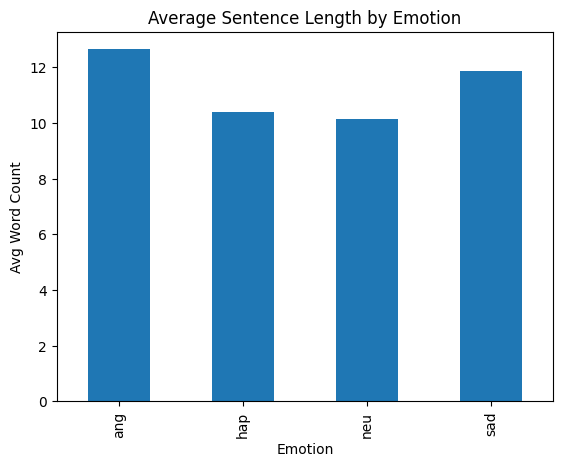

In [17]:
import matplotlib.pyplot as plt

df.groupby("emotion")["length"].mean().plot(kind="bar")
plt.title("Average Sentence Length by Emotion")
plt.xlabel("Emotion")
plt.ylabel("Avg Word Count")
plt.show()

In [18]:
ang_words = " ".join(df[df["emotion"]=="ang"]["transcript"]).lower().split()
sad_words = " ".join(df[df["emotion"]=="sad"]["transcript"]).lower().split()

print("Angry:", Counter(ang_words).most_common(10))
print("Sad:", Counter(sad_words).most_common(10))

Angry: [('i', 597), ('you', 575), ('to', 380), ('the', 295), ('a', 276), ('and', 262), ('is', 157), ('what', 155), ('of', 150), ("don't", 145)]
Sad: [('i', 771), ('you', 468), ('to', 416), ('and', 343), ('the', 232), ('a', 201), ('of', 184), ('that', 183), ('it', 182), ('was', 175)]


In [19]:
import os

wav_path = "/content/drive/MyDrive/iemocap/IEMOCAP_full_release/Session1/dialog/wav"
print(os.listdir(wav_path)[:10])

[]


In [20]:
import os

base = "/content/drive/MyDrive/iemocap/IEMOCAP_full_release/Session1"

for root, dirs, files in os.walk(base):
    if any(f.endswith(".wav") for f in files):
        print("FOUND WAV FILES IN:", root)
        break

FOUND WAV FILES IN: /content/drive/MyDrive/iemocap/IEMOCAP_full_release/Session1/sentences/wav/Ses01M_script03_2


In [21]:
!pip install librosa

In [22]:
import librosa
import numpy as np
import os

def extract_features(file_path):
    try:
        y, sr = librosa.load(file_path, sr=None)

        mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13), axis=1)
        energy = np.mean(y**2)
        zcr = np.mean(librosa.feature.zero_crossing_rate(y))

        return np.hstack([mfcc, energy, zcr])

    except:
        return None

In [23]:
df_small = df.sample(500, random_state=42).reset_index(drop=True)

In [24]:
audio_features = []
valid_rows = []

base_audio_path = "/content/drive/MyDrive/iemocap/IEMOCAP_full_release"

for i, row in df_small.iterrows():
    utt_id = row["utterance_id"]

    found = False

    for session in range(1, 6):
        wav_root = os.path.join(base_audio_path, f"Session{session}", "sentences", "wav")

        for root, dirs, files in os.walk(wav_root):
            if f"{utt_id}.wav" in files:
                file_path = os.path.join(root, f"{utt_id}.wav")

                feats = extract_features(file_path)
                if feats is not None:
                    audio_features.append(feats)
                    valid_rows.append(i)

                found = True
                break
        if found:
            break

# Filter dataframe
df_audio = df_small.iloc[valid_rows].reset_index(drop=True)
X_audio = np.array(audio_features)

print("Audio samples:", len(X_audio))

Audio samples: 500


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X_audio, df_audio["emotion"], test_size=0.2, random_state=42
)

model_audio = LogisticRegression(max_iter=1000) # Increased max_iter
model_audio.fit(X_train, y_train)

y_pred_audio = model_audio.predict(X_test)

print("ACOUSTIC MODEL")
print(classification_report(y_test, y_pred_audio))

ACOUSTIC MODEL
              precision    recall  f1-score   support

         ang       0.78      0.62      0.69        29
         hap       0.67      0.15      0.25        13
         neu       0.47      0.74      0.58        35
         sad       0.63      0.52      0.57        23

    accuracy                           0.58       100
   macro avg       0.64      0.51      0.52       100
weighted avg       0.62      0.58      0.57       100



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_combined_scaled = scaler.fit_transform(X_combined)

X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X_combined_scaled, df_audio["emotion"], test_size=0.2, random_state=42
)

model_combined_scaled = LogisticRegression(max_iter=1000)
model_combined_scaled.fit(X_train_scaled, y_train)

y_pred_combined_scaled = model_combined_scaled.predict(X_test_scaled)

print("COMBINED MODEL (SCALED DATA)")
print(classification_report(y_test, y_pred_combined_scaled))

NameError: name 'X_combined' is not defined

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X_text = vectorizer.fit_transform(df_audio["transcript"]).toarray()

In [29]:
X_combined = np.hstack([X_text, X_audio])

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, df_audio["emotion"], test_size=0.2, random_state=42
)

model_combined = LogisticRegression(max_iter=200)
model_combined.fit(X_train, y_train)

y_pred_combined = model_combined.predict(X_test)

print("COMBINED MODEL")
print(classification_report(y_test, y_pred_combined))

COMBINED MODEL
              precision    recall  f1-score   support

         ang       0.79      0.52      0.62        29
         hap       0.00      0.00      0.00        13
         neu       0.44      0.74      0.55        35
         sad       0.57      0.52      0.55        23

    accuracy                           0.53       100
   macro avg       0.45      0.45      0.43       100
weighted avg       0.51      0.53      0.50       100



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale ONLY audio features
scaler = StandardScaler()
X_audio_scaled = scaler.fit_transform(X_audio)

# Combine with text features
X_text = vectorizer.transform(df_audio["transcript"]).toarray()
X_combined = np.hstack([X_text, X_audio_scaled])

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, df_audio["emotion"], test_size=0.2, random_state=42
)

# Improved model
model_combined = LogisticRegression(max_iter=1000)
model_combined.fit(X_train, y_train)

y_pred_combined = model_combined.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_combined))

              precision    recall  f1-score   support

         ang       0.83      0.66      0.73        29
         hap       0.60      0.23      0.33        13
         neu       0.50      0.71      0.59        35
         sad       0.59      0.57      0.58        23

    accuracy                           0.60       100
   macro avg       0.63      0.54      0.56       100
weighted avg       0.63      0.60      0.59       100



In [32]:
with open("combined_results.txt", "w") as f:
    f.write(classification_report(y_test, y_pred_combined))

In [33]:
X_text = vectorizer.transform(df_audio["transcript"]).toarray()
y = df_audio["emotion"]

In [34]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42
)

X_train_audio, X_test_audio, _, _ = train_test_split(
    X_audio_scaled, y, test_size=0.2, random_state=42
)

X_train_combined, X_test_combined, _, _ = train_test_split(
    X_combined, y, test_size=0.2, random_state=42
)

In [35]:
model_text = LogisticRegression(max_iter=1000)
model_text.fit(X_train_text, y_train)

y_pred_text = model_text.predict(X_test_text)

In [36]:
model_audio = LogisticRegression(max_iter=1000)
model_audio.fit(X_train_audio, y_train)

y_pred_audio = model_audio.predict(X_test_audio)

In [37]:
model_combined = LogisticRegression(max_iter=1000)
model_combined.fit(X_train_combined, y_train)

y_pred_combined = model_combined.predict(X_test_combined)

In [38]:
from sklearn.metrics import classification_report

print("TEXT MODEL")
print(classification_report(y_test, y_pred_text))

print("AUDIO MODEL")
print(classification_report(y_test, y_pred_audio))

print("COMBINED MODEL")
print(classification_report(y_test, y_pred_combined))

TEXT MODEL
              precision    recall  f1-score   support

         ang       0.50      0.28      0.36        29
         hap       1.00      0.15      0.27        13
         neu       0.39      0.77      0.52        35
         sad       0.46      0.26      0.33        23

    accuracy                           0.43       100
   macro avg       0.59      0.37      0.37       100
weighted avg       0.52      0.43      0.40       100

AUDIO MODEL
              precision    recall  f1-score   support

         ang       0.70      0.55      0.62        29
         hap       0.00      0.00      0.00        13
         neu       0.45      0.71      0.56        35
         sad       0.57      0.52      0.55        23

    accuracy                           0.53       100
   macro avg       0.43      0.45      0.43       100
weighted avg       0.49      0.53      0.50       100

COMBINED MODEL
              precision    recall  f1-score   support

         ang       0.83      0.66    

In [39]:
with open("final_results.txt", "w") as f:
    f.write("TEXT MODEL\n")
    f.write(classification_report(y_test, y_pred_text))
    f.write("\n\nAUDIO MODEL\n")
    f.write(classification_report(y_test, y_pred_audio))
    f.write("\n\nCOMBINED MODEL\n")
    f.write(classification_report(y_test, y_pred_combined))

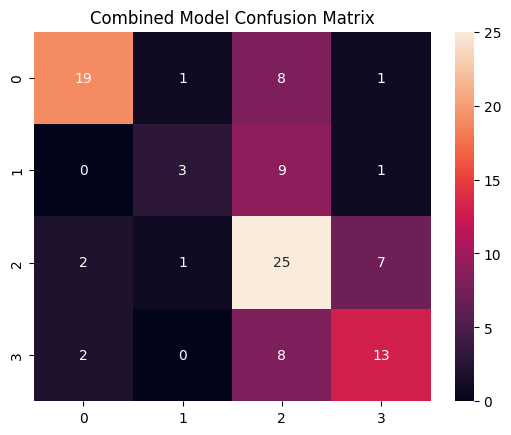

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_combined)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Combined Model Confusion Matrix")
plt.show()

In [41]:
!pip install statsmodels

In [42]:
from statsmodels.stats.contingency_tables import mcnemar

# Correct/incorrect predictions
text_correct = (y_pred_text == y_test)
combined_correct = (y_pred_combined == y_test)

In [43]:
import numpy as np

# Table:
# [[both correct, text correct only],
#  [combined correct only, both wrong]]

table = np.zeros((2,2))

for t, c in zip(text_correct, combined_correct):
    if t and c:
        table[0,0] += 1
    elif t and not c:
        table[0,1] += 1
    elif not t and c:
        table[1,0] += 1
    else:
        table[1,1] += 1

print(table)

[[35.  8.]
 [25. 32.]]


In [44]:
result = mcnemar(table, exact=True)

print("Statistic:", result.statistic)
print("p-value:", result.pvalue)

Statistic: 8.0
p-value: 0.004551384132355452


In [45]:
audio_correct = (y_pred_audio == y_test)
combined_correct = (y_pred_combined == y_test)